# **Istanbul Rental Market & Walkability Analysis**
# Project P1: Problem & EDA

# 1. Problem Formulation

**Problem Definition**

The Istanbul rental market is influenced by a complex mix of structural and locational factors. This project aims to quantify these influences by analyzing a large-scale real estate dataset. Our primary focus is on Walkability—a derived socio-economic metric representing accessibility to urban amenities—and its direct impact on rental prices compared to traditional features like size and district prestige.

**Our Goal:**
* Data Engineering: Transform raw web-scraped data into a structured, machine-learning-ready format.
* Strategic Insight: Identify the most cost-effective and "walkable" districts optimized for student life.
* Feature Engineering: Develop a custom "Walkability Score" incorporating transport proximity, university density, and social hubs.
* Correlation Analysis: Analyze the mathematical relationship between walkability and price.

_This project is the first step for our Machine Learning model._

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.preprocessing import MinMaxScaler


# Gorsellestirmelerin notebook icinde gorunmesi icin
%matplotlib inline

# Veriyi yukle
df = pd.read_csv('../data/istanbul_emlak_data.csv')

# Ilk birkac satira goz atalim
df.head()

,price,area_m2,room_count,district,neighborhood
0,13.000 TL,85.0,2+1,Esenyurt,NaN
1,14.000 TL,95.0,2+1,Esenyurt,NaN
2,12.500 TL,130.0,3+1,Başakşehir,İkitelli
3,13.000 TL,90.0,2+1,Esenyurt,NaN
4,14.000 TL,150.0,3+1,Esenyurt,NaN


### _Stage1: Initial Data Inspection(Missing Values)_
First, we look at the raw data. The yellow lines in the Heatmap show where information is missing. We need to see how "dirty" our data is before cleaning.

This heatmap serves as the initial "Data Quality Audit." It visualizes the gaps in our raw dataset where information was not provided during the scraping process.

In [2]:
# Temizlik oncesi heat map
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Stage 1: Missing Values")

# Kiyaslama icin png kaydet.
plt.savefig('../plots/stage1_missing_values.png', dpi=300, bbox_inches='tight')
plt.show()

print("Eksik veri sayisi (Raw Data):")
print(df.isnull().sum())

Eksik veri sayisi (Raw Data):
price           1063
area_m2         1063
room_count      1063
district        1063
neighborhood    3326
dtype: int64


_The prominent yellow streaks in the neighborhood and price columns indicate significant data loss, highlighting the immediate need for a robust cleaning pipeline to prevent model bias._

# 2. Data Cleaning & Standardization

Raw data is "dirty." Prices have "TL" and areas have "m2" text.
Computers only understand numbers. We change strings to floats.

**What we do here:**
* Remove "TL" and dots from Price.
* Remove "m2" from Area.
* Change "2+1" room count to total number (3.0).
* Fix District & Neighborhood:Some neighborhoods (like Taksim) were in the District column. We moved them to the correct place.

In [3]:
# Fiyati temizle ("25.000 TL" -> 25000)
def clean_price(price_str):
    if pd.isna(price_str): return np.nan
    # Rakam disindaki her seyi (TL, nokta vb.) temizle
    price = re.sub(r'[^\d]', '', str(price_str))
    return float(price) if price else np.nan

# Metrekareyi temizle ("120 m2" -> 120)
def clean_m2(m2_str):
    if pd.isna(m2_str): return np.nan
    # Sadece 'm2' yazisini ve bosluklari temizle, noktaya dokunma
    m2 = str(m2_str).replace('m2', '').replace(' ', '').strip()
    return float(m2) if m2 else np.nan

# Oda sayisini sayisal toplama cevir.
def simple_room_count(room_str):
    # Bos veri veya 'stüdyo' kontrolu
    if pd.isna(room_str) or 'stüdyo' in str(room_str).lower():
        return 1.0

    try:
        # "+" isaretinden bol ve her parcayi float yapip topla.
        return sum(float(part) for part in str(room_str).split('+'))
    except:
        # Eger garip bir format gelirse (bosluk vs) 0 don.
        return 0.0

In [4]:
# Uygula.
df['price'] = df['price'].apply(clean_price)
df['area_m2'] = df['area_m2'].apply(clean_m2)
df['total_rooms'] = df['room_count'].apply(simple_room_count)

# Sutunlari temizle.
df['room_count'] = df['room_count'].str.strip()

print("Temizleme sonrası veri tipleri:\n", df.dtypes)
df.head()

,price,area_m2,room_count,district,neighborhood,total_rooms
0,13000.0,85.0,2+1,Esenyurt,NaN,3.0
1,14000.0,95.0,2+1,Esenyurt,NaN,3.0
2,12500.0,130.0,3+1,Başakşehir,İkitelli,4.0
3,13000.0,90.0,2+1,Esenyurt,NaN,3.0
4,14000.0,150.0,3+1,Esenyurt,NaN,4.0


In [5]:
# Yazim hatalarini ve karakterleri standartlastir.
# Analizlerin ve Walkability Score'un dogru calismasi icin isimlerin birebir uymasi gerekir.
df['district'] = df['district'].replace({
    'Besiktas': 'Beşiktaş', 'Kadikoy': 'Kadıköy', 'Sisli': 'Şişli',
    'Uskudar': 'Üsküdar', 'Beyoglu': 'Beyoğlu', 'Basaksehir': 'Başakşehir',
    'Arnavutkoy': 'Arnavutköy', 'Bagcilar': 'Bağcılar', 'Bahcelievler': 'Bahçelievler',
    'Bakirkoy': 'Bakırköy', 'Bayrampasa': 'Bayrampaşa', 'Beylikduzu': 'Beylikdüzü',
    'Buyukcekmece': 'Büyükçekmece', 'Catalca': 'Çatalca', 'Cekmekoy': 'Çekmeköy',
    'Eyupsultan': 'Eyüpsultan', 'Gaziosmanpasa': 'Gaziosmanpaşa', 'Gungoren': 'Güngören',
    'Kagithane': 'Kağıthane', 'Kucukcekmece': 'Küçükçekmece', 'Sariyer': 'Sarıyer',
    'Sile': 'Şile', 'Umraniye': 'Ümraniye', 'Zeytinburnu': 'Zeytinburnu'
})

In [6]:
# Mahalle-Ilce Eslestirme
# Ilce sutununa kacmis olan mahalleleri ve bagli olduklari asil ilceleri tanimla.
location_fix = {
    # Beyoglu Mahalleleri
    'Taksim': 'Beyoğlu', 'Cihangir': 'Beyoğlu', 'Tarlabaşı': 'Beyoğlu', 'Kasımpaşa': 'Beyoğlu',
    'Halıcıoğlu': 'Beyoğlu', 'Yenişehir': 'Beyoğlu', 'Pürtelaş': 'Beyoğlu', 'İstiklal': 'Beyoğlu',
    'Kemankeş': 'Beyoğlu', 'Arapcami': 'Beyoğlu', 'Gümüşsuyu': 'Beyoğlu', 'Sütlüce': 'Beyoğlu',
    # Şişli Mahalleleri
    'Nişantaşı': 'Şişli', 'Mecidiyeköy': 'Şişli', 'Feriköy': 'Şişli', 'Fulya': 'Şişli',
    'Gayrettepe': 'Şişli', 'Harbiye': 'Şişli', 'Teşvikiye': 'Şişli', 'Okmeydanı': 'Şişli',
    'Gülbahar': 'Şişli', 'Halide Edip': 'Şişli', 'Duatepe': 'Şişli', 'Bozkurt': 'Şişli',
    'Meşrutiyet': 'Şişli', 'Esentepe': 'Şişli', 'Kuştepe': 'Şişli', 'Bomonti': 'Şişli',
    # Kadikoy Mahalleleri
    'Acıbadem': 'Kadıköy', 'Moda': 'Kadıköy', 'Fenerbahçe': 'Kadıköy', 'Caddebostan': 'Kadıköy',
    'Göztepe': 'Kadıköy', 'Bostancı': 'Kadıköy', 'Erenköy': 'Kadıköy', 'Suadiye': 'Kadıköy',
    'Sahrayıcedit': 'Kadıköy', 'Hasanpaşa': 'Kadıköy', 'Rasimpaşa': 'Kadıköy', 'Zühtüpaşa': 'Kadıköy',
    'Fikirtepe': 'Kadıköy', 'Merdivenköy': 'Kadıköy', 'Kozyatağı': 'Kadıköy', '19 Mayıs': 'Kadıköy',
    'Caferağa': 'Kadıköy', 'Kalamış': 'Kadıköy',
    # Besiktas Mahalleleri
    'Ortaköy': 'Beşiktaş', 'Bebek': 'Beşiktaş', 'Etiler': 'Beşiktaş', 'Levent': 'Beşiktaş',
    'Ulus': 'Beşiktaş', 'Gayrettepe': 'Beşiktaş', 'Levazım': 'Beşiktaş', 'Kuruçeşme': 'Beşiktaş',
    'Balmumcu': 'Beşiktaş', 'Akat': 'Beşiktaş', 'Dikilitaş': 'Beşiktaş', 'Yıldız': 'Beşiktaş',
    # Uskudar Mahalleleri
    'Kuzguncuk': 'Üsküdar', 'Beylerbeyi': 'Üsküdar', 'Çengelköy': 'Üsküdar', 'Kandilli': 'Üsküdar',
    'Altunizade': 'Üsküdar', 'Burhaniye': 'Üsküdar', 'Selimiye': 'Üsküdar', 'Zeynep Kamil': 'Üsküdar',
    'Bağlarbaşı': 'Üsküdar', 'Doğancılar': 'Üsküdar', 'Küçüksu': 'Üsküdar', 'Kuleli': 'Üsküdar',
    # Maltepe Mahalleleri
    'Küçükyalı': 'Maltepe', 'İdealtepe': 'Maltepe', 'Zümrütevler': 'Maltepe', 'Feyzullah': 'Maltepe',
    'Cevizli': 'Maltepe', 'Başıbüyük': 'Maltepe', 'Aydınevler': 'Maltepe', 'Yalı': 'Maltepe',
    # Sariyer Mahalleleri
    'Büyükdere': 'Sarıyer', 'İstinye': 'Sarıyer', 'Rumelihisarı': 'Sarıyer', 'Tarabya': 'Sarıyer',
    'Emirgan': 'Sarıyer', 'Bahçeköy': 'Sarıyer', 'Zekeriyaköy': 'Sarıyer', 'Yeniköy': 'Sarıyer',
    # Zeytinburnu Mahalleleri
    'Merkezefendi': 'Zeytinburnu', 'Beştelsiz': 'Zeytinburnu', 'Çırpıcı': 'Zeytinburnu', 'Seyitnizam': 'Zeytinburnu',
    # Atasehir Mahalleleri
    'İçerenköy': 'Ataşehir', 'Küçükbakkalköy': 'Ataşehir', 'Barbaros': 'Ataşehir', 'Kayışdağı': 'Ataşehir',
    # Umraniye Mahalleleri
    'Çakmak': 'Ümraniye', 'Ihlamurkuyu': 'Ümraniye', 'Dudullu': 'Ümraniye', 'Atakent': 'Ümraniye', 'Esenevler': 'Ümraniye',
    # Bagcilar Mahalleleri
    'Güneşli': 'Bağcılar', 'Mahmutbey': 'Bağcılar', 'Kirazlı': 'Bağcılar', 'Hürriyet': 'Bağcılar',
    # Eyupsultan Mahalleleri
    'Alibeyköy': 'Eyüpsultan', 'Göktürk': 'Eyüpsultan', 'Kemerburgaz': 'Eyüpsultan', 'Yeşilpınar': 'Eyüpsultan',
    # Diger
    'Kumburgaz': 'Büyükçekmece', 'Mimarsinan': 'Büyükçekmece', 'Tepecik': 'Büyükçekmece',
    'Celaliye(Kamiloba)': 'Büyükçekmece', 'Kamiloba': 'Büyükçekmece',
    'İkitelli': 'Başakşehir', 'Sultançiftliği': 'Sultangazi', 'Anadoluhisarı': 'Beykoz'
}

# Mahalle eklerini ve bosluklari temizle ("Taksim Mh." -> "Taksim")
df['district'] = df['district'].str.replace(r'\s+(Mh\.?|Mah\.?|Mahallesi)$', '', regex=True).str.strip()
df['neighborhood'] = df['neighborhood'].str.replace(r'\s+(Mh\.?|Mah\.?|Mahallesi)$', '', regex=True).str.strip()

# Swapping: Eger ilce sutununda bir mahalle adi varsa onu once 'neighborhood' sutununa tasi,
# sonra 'district' sutununu gercek ilcesiyle guncelle.
for wrong_name, correct_district in location_fix.items():
    # Eger mahalle bilgisi bossa, ilce sutunundaki mahalle adini oraya kopyala.
    df.loc[(df['district'] == wrong_name) & (df['neighborhood'].isna()), 'neighborhood'] = wrong_name
    # Sonra ilce adini duzelt.
    df.loc[df['district'] == wrong_name, 'district'] = correct_district

# Bos mahalleleri "Merkez" olarak isaretle.(Swapping sonrası hala verisi olmayan yerler artik resmen o ilcenin 'Merkez'idir.)
df['neighborhood'] = df['neighborhood'].fillna('Merkez')

print("Konum duzeltme ve veri kaydirma tamamlandi.")
print(f"Guncel Benzersiz Ilce Sayisi: {df['district'].nunique()}")

Konum duzeltme ve veri kaydirma tamamlandi.
Guncel Benzersiz Ilce Sayisi: 80


# 3. Feature Engineering

### Walkability Score (Urban Accessibility)

Students need to walk to university or transport.The walkability score is a custom feature designed to quantify how accessible a property is to essential urban amenities.

The score is computed based on the presence of nearby facilities such as:
* Public transportation
* Markets and grocery stores
* Universities
* Social areas

Each component contributes to the total score with predefined weights:
* Transportation (0.5): Proximity to Metro, Metrobus, and Ferry lines.
* Universities (0.3): Concentration of campus locations and faculties.
* Social & Markets (0.2): Availability of cafes, libraries, and grocery stores.

The final score is normalized to a scale between 0 and 100.

$$Score = (Transport \times 0.5) + (University \times 0.3) + (Social \times 0.2)$$

In [7]:
# Ham Istatistikler (IBB, YÖK ve Sosyal Endeks yaklaşık verileri)
# 1. stations: Metro, Metrobus, Marmaray, Vapur durak sayisi
# 2. univ_campuses: Ilce sinirlarindaki aktif yerleske/fakulte sayisi
# 3. social_points: Sosyal imkanlar (kafe, kutuphane, yesil alan) yogunluk puani (0-100)
raw_stats = {
    'Beşiktaş':    {'stations': 12, 'univ_campuses': 10, 'social_points': 95},
    'Kadıköy':     {'stations': 15, 'univ_campuses': 6,  'social_points': 98},
    'Beyoğlu':     {'stations': 14, 'univ_campuses': 5,  'social_points': 100},
    'Şişli':       {'stations': 14, 'univ_campuses': 8,  'social_points': 90},
    'Fatih':       {'stations': 18, 'univ_campuses': 12, 'social_points': 75},
    'Üsküdar':     {'stations': 10, 'univ_campuses': 5,  'social_points': 80},
    'Sarıyer':     {'stations': 8,  'univ_campuses': 9,  'social_points': 80},
    'Ataşehir':    {'stations': 8,  'univ_campuses': 4,  'social_points': 80},
    'Bakırköy':    {'stations': 9,  'univ_campuses': 4,  'social_points': 85},
    'Zeytinburnu': {'stations': 12, 'univ_campuses': 4,  'social_points': 65},
    'Ümraniye':    {'stations': 10, 'univ_campuses': 2,  'social_points': 65},
    'Eyüpsultan':  {'stations': 9,  'univ_campuses': 3,  'social_points': 60},
    'Kağıthane':   {'stations': 7,  'univ_campuses': 3,  'social_points': 55},
    'Kartal':      {'stations': 8,  'univ_campuses': 2,  'social_points': 60},
    'Avcılar':     {'stations': 6,  'univ_campuses': 7,  'social_points': 50},
    'Maltepe':     {'stations': 7,  'univ_campuses': 4,  'social_points': 65},
    'Bağcılar':    {'stations': 12, 'univ_campuses': 3,  'social_points': 45},
    'Esenyurt':    {'stations': 3,  'univ_campuses': 2,  'social_points': 35},
    'Beylikdüzü':  {'stations': 4,  'univ_campuses': 2,  'social_points': 45},
    'Silivri':     {'stations': 1,  'univ_campuses': 1,  'social_points': 20}
}

# Ham veriyi DataFrame'e cevir.
stats_df = pd.DataFrame.from_dict(raw_stats, orient='index')

# Normalizasyon (0-100): En yuksek sayiya sahip olan ilce 100 puan alacak sekilde
def normalize(column):
    return (column - column.min()) / (column.max() - column.min()) * 100

stats_df['transport_score'] = normalize(stats_df['stations'])
stats_df['univ_score'] = normalize(stats_df['univ_campuses'])
stats_df['social_score'] = normalize(stats_df['social_points'])

# Formülü Uygula: Transport (%50), University (%30), Social (%20)
stats_df['final_walkability_score'] = (
    (stats_df['transport_score'] * 0.5) +
    (stats_df['univ_score'] * 0.3) +
    (stats_df['social_score'] * 0.2)
).round(2)

# Veriye uygula.
# Onemli: Gizli bosluklari temizleyerek eslesmeyi garanti altina aliyoruz.
df['district'] = df['district'].str.strip()
final_metrics_map = stats_df['final_walkability_score'].to_dict()
df['walkability_score'] = df['district'].map(final_metrics_map).fillna(10.0)

# Kontrol et.
print("Veriden Türetilmiş Skorlar (Normalizasyon Sonrası):")
print(stats_df[['transport_score', 'univ_score', 'social_score', 'final_walkability_score']].sort_values(by='final_walkability_score', ascending=False))

Veriden Türetilmiş Skorlar (Normalizasyon Sonrası):
             transport_score  univ_score  social_score  \
Fatih             100.000000  100.000000         68.75   
Beşiktaş           64.705882   81.818182         93.75   
Şişli              76.470588   63.636364         87.50   
Kadıköy            82.352941   45.454545         97.50   
Beyoğlu            76.470588   36.363636        100.00   
Sarıyer            41.176471   72.727273         75.00   
Üsküdar            52.941176   36.363636         75.00   
Zeytinburnu        64.705882   27.272727         56.25   
Bakırköy           47.058824   27.272727         81.25   
Bağcılar           64.705882   18.181818         31.25   
Ataşehir           41.176471   27.272727         75.00   
Ümraniye           52.941176    9.090909         56.25   
Eyüpsultan         47.058824   18.181818         50.00   
Avcılar            29.411765   54.545455         37.50   
Maltepe            35.294118   27.272727         56.25   
Kartal             4

### Saving the Scored Dataset
Now our data has a "Walkability Score." We save it as a new CSV file.

In [8]:
# index=False (basa gereksiz 0,1,2... sutunu eklemesin)
df.to_csv('../data/istanbul_emlak_walkability.csv', index=False)

print("Veri 'istanbul_emlak_walkability.csv' adıyla kaydedildi.")

Veri 'istanbul_emlak_walkability.csv' adıyla kaydedildi.


### Student-Friendly Score

A prime location is not necessarily "ideal" for a student if the rent is prohibitive. This index identifies "Sweet Spots" by balancing Accessibility with Affordability.

**Logic:**

* Inverted Price Score: Since lower rent is better for students, we normalize the price and subtract it from 1 (1−Price
norm
​
 ), ensuring that cheaper listings receive a higher score.

* Optimization: It filters out ultra-luxury areas and highlights neighborhoods where high walkability meets reasonable costs.

**Formula:**

Score
Student
​
 =(Score
Walkability
​
 ×0.5)+(Inverted_Price_Score×0.5)
Weighting: By assigning 50% to Walkability and 50% to Affordability, this metric pinpoints the most optimized residential zones for the student demographic in Istanbul.

In [9]:
# Scaler olustur.
scaler = MinMaxScaler()

# 2. Fiyati normalize et (0-1 arası) ve tersine cevir.
# (Yuksek fiyat = Dusuk puan olmasi icin 1'den cikar.)
df['price_normalized'] = scaler.fit_transform(df[['price']])
df['price_score'] = (1 - df['price_normalized']) * 100

# Ogrenci Uygunluk Skorunu Hesapla (%50 Yurunebilirlik, %50 Ucuzluk)
df['student_score'] = (df['walkability_score'] * 0.5) + (df['price_score'] * 0.5)

# 2 basamaga yuvarla
df['student_score'] = df['student_score'].round(2)

# Ara islemleri temizleyip sadece final skorunu tut.
df.drop(['price_normalized', 'price_score'], axis=1, inplace=True)

# Kontrol: En yuksek skorlu 5 ilce/mahalle
print(df[['district', 'neighborhood', 'price', 'walkability_score', 'student_score']].sort_values(by='student_score', ascending=False).head())

      district neighborhood    price  walkability_score  student_score
9328     Fatih       Haseki  10000.0              93.75          96.88
970      Fatih    Fevzipaşa  10000.0              93.75          96.88
16302    Fatih      Akdeniz  10000.0              93.75          96.88
1015     Fatih       Haseki  10000.0              93.75          96.88
16419    Fatih       Haseki  10000.0              93.75          96.88


### Saving the Scored Dataset
Now our data has a "Student Score." We save it as a new CSV file.

In [10]:
df.to_csv('../data/istanbul_emlak_student.csv', index=False)

print("Veri 'istanbul_emlak_student.csv' adıyla kaydedildi.")

Veri 'istanbul_emlak_student.csv' adıyla kaydedildi.


### _Stage 2: Outlier Analysis (Before Cleaning)_
We check the data before removing outliers.
Some data is not realistic. For example, houses with 1500 $m^2$ area.
These "Outliers" break our graphs and models.
We see these spikes in the red histograms below.
This "noise" makes our graphs look bad.

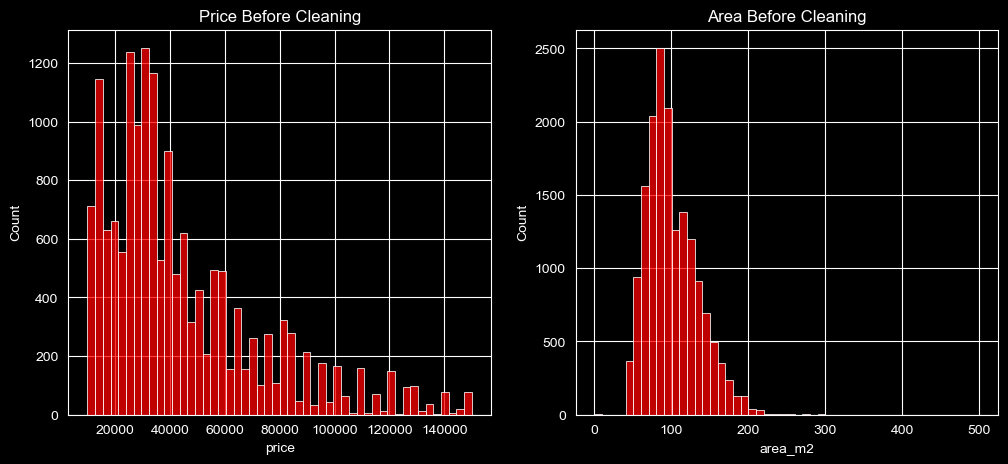

In [11]:
df = pd.read_csv('../data/istanbul_emlak_walkability.csv')

# Fiyat dagilimi (Kirmizi)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['price'], bins=50, color='red')
plt.title('Price Before Cleaning')

# Metrekare dagilimi (Kirmizi)
plt.subplot(1, 2, 2)
sns.histplot(df['area_m2'], bins=50, color='red')
plt.title('Area Before Cleaning')

# Kiyaslama icin png kaydet.
plt.savefig('../plots/stage2_dirty_distribution.png', dpi=300)
plt.show()

_The extreme right-skewness and 'spikes' at near-zero or million-plus values represent unrealistic outliers (e.g., 1 TL rents or massive land plots) that would degrade the performance of any regression model._

# 4. Statistical Outlier Removal & Data Integrity

### Handling Missing Values and Outliers

Method: Domain-Based Threshold Filtering

To ensure data quality and reliability, both missing values and unrealistic observations were addressed.

First, rows with missing critical values were removed. Listings without essential attributes such as price, area (m²), or district were excluded, as they cannot contribute to meaningful analysis or modeling.

Outliers were handled using domain-based threshold filtering, where limits were defined based on knowledge of the Istanbul real estate market rather than purely statistical methods.

What we do:
* Missing Value Removal: We eliminated incomplete records using dropna. Listings missing critical features like price, area, or district cannot be used for accurate machine learning predictions.
* Price Filtering: We kept listings between 5,000 TL and 200,000 TL. This removes "noise" like fake daily rentals (very low) or luxury mansions/errors (extreme high) that would skew the model's average.
* Area Filtering: We set a logical limit between 30 m2 and 500 m2.This ensures the model focuses on standard residential apartments, removing tiny storage units or massive industrial plots.

Result: This filtering process reduces noise and improves the representativeness of the dataset, allowing for more reliable exploratory analysis and better generalization in subsequent regression models.

In [12]:
df = pd.read_csv('../data/istanbul_emlak_student.csv')

# Null veya kritik verisi eksik olan satirlari sil. (Fiyat ve metrekare olmayan satirlar isimize yaramaz)
df = df.dropna(subset=['price', 'area_m2', 'district'])

# Outliers: Istanbul icin gercekci olmayan kira ve metrekare
df = df[(df['price'] > 5000) & (df['price'] < 200000)] # 5k altı ve 200k ustu gitsin
df = df[(df['area_m2'] > 30) & (df['area_m2'] < 500)] # 30m2 alti ve 500m2 ustu gitsin

# Sonuclari kontrol et
print(f"Temizlik sonrası kalan ilan sayısı: {len(df)}")
df.head()

,price,area_m2,room_count,district,neighborhood,total_rooms,walkability_score,student_score
0,13000.0,85.0,2+1,Esenyurt,Merkez,3.0,12.36,55.11
1,14000.0,95.0,2+1,Esenyurt,Merkez,3.0,12.36,54.75
2,12500.0,130.0,3+1,Başakşehir,İkitelli,4.0,10.00,54.11
3,13000.0,90.0,2+1,Esenyurt,Merkez,3.0,12.36,55.11
4,14000.0,150.0,3+1,Esenyurt,Merkez,4.0,12.36,54.75


### Saving the Final Dataset
Now our data is clean and has a "Walkability Score."
We save it as a new CSV file.

In [13]:
# index=False (basa gereksiz 0,1,2... sutunu eklemesin)
df.to_csv('../data/istanbul_emlak_final.csv', index=False)

print("Temizlenmiş veri 'istanbul_emlak_final.csv' adıyla kaydedildi.")

Temizlenmiş veri 'istanbul_emlak_final.csv' adıyla kaydedildi.


### _Stage 3: Final Data Quality Check & Comparison_
Now we check the data again.
The Heatmap should be solid (no yellow lines).
The Green histograms show that our data is now realistic and "Clean."

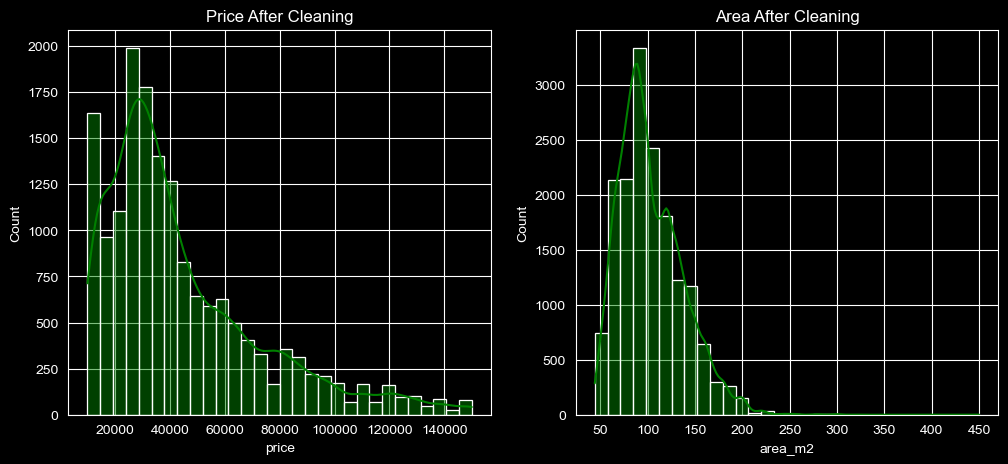

In [14]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')
# Heat Map: Temizlik ve Outlier isleminden sonraki eksik veri görsellestirmesi
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Eksik Veri Matrisi (AFTER CLEANING)")
plt.show()

# Sutun bazinda eksik veri sayilarini tekrar kontrol et. (hepsi 0 olmali)
print("Eksik değer sayısı (Missing values count):\n")
print(df.isnull().sum())

# Temizlik sonrasi dagilim (Yesil = daha duzenli)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['price'], bins=30, kde=True, color='green')
plt.title('Price After Cleaning')

plt.subplot(1, 2, 2)
sns.histplot(df['area_m2'], bins=30, kde=True, color='green')
plt.title('Area After Cleaning')

# Kiyaslama icin png kaydet.
plt.savefig('../plots/stage3_final_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

_The solid, uniform color profile confirms a 100% complete dataset; our 'Standardization Gatekeeper' has ensured the data is now structurally sound and ML-Ready._

# 4. Visualization

### Data Processing

We successfully transformed raw real estate data into a structured, student-friendly dataset.
Below is the step-by-step visualization of our cleaning process:

---

#### **Stage 1: The Starting Point (Raw Data)**
We started with "dirty" data. The yellow lines in the heatmap represent missing information that could mislead our model.
<img src="../plots/stage1_missing_values.png" width="100%">

---

#### **Stage 2: Feature Engineering (Walkability Score Integration)**
In this stage, we standardized district names and calculated our custom Walkability Index for every listing.
<img src="../plots/stage2_dirty_distribution.png" width="100%">

---

#### **Stage 3: Final Cleaning & Outlier Removal (ML-Ready)**
Our final dataset has **zero missing values** (solid purple) and includes our custom **Walkability Score**. We are now ready for the Regression phase.
<img src="../plots/stage3_final_heatmap.png" width="100%">

---

### Relationship between Walkability and Rent Prices (Correlation Heatmap)
We want to see if "Walkable" districts are more expensive. Usually, Beşiktaş and Kadıköy are expensive because they are student-friendly.

A **Correlation Matrix** is a table that shows the numerical relationship between variables.
The correlation coefficient ranges from **-1 to 1**:

* Near 1.0 (Red): Strong positive relationship. If one variable increases, the other also increases.
* Near 0.0: No relationship between the variables.
* Near -1.0 (Blue): Strong negative relationship. If one increases, the other decreases.

**Why are we doing this?**
We want to see the "Impact Power" of our **Walkability Score** on the **Price**.
If the number is high (above 0.50), it proves our student-friendly scoring is a major factor in Istanbul's housing market.

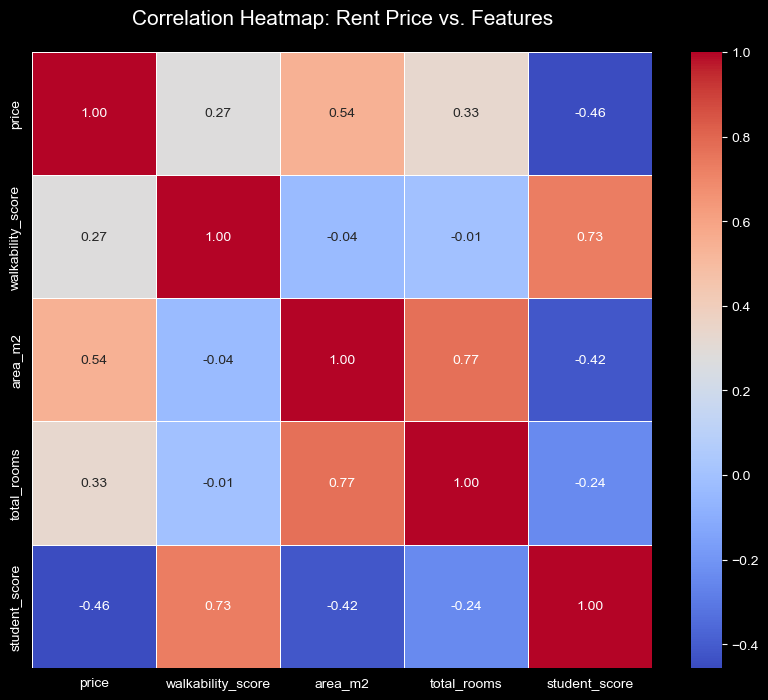

In [15]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

# Sutunların sayisal oldugundan emin ol.
cols_to_use = ['price', 'walkability_score', 'area_m2', 'total_rooms' , 'student_score' ]
for col in cols_to_use:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Sadece bu sutunları iceren ve eksik verisi olmayan bir alt kume al.
corr_data = df[cols_to_use].dropna()

# Korelasyon hesapla.
correlation = corr_data.corr()

# Gorsellestirme
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Rent Price vs. Features', fontsize=15, pad=20)

plt.savefig('../plots/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
# Korelasyon katsayisini yorumla.
walk_corr = correlation.loc['price', 'walkability_score']
print(f"\nYürünebilirlik ve fiyat arasındaki korelasyon: {walk_corr:.2f}")

if walk_corr > 0.5:
    print("Sonuç: Yürünebilirliğin kira fiyatları üzerinde güçlü bir pozitif etkisi var.")
elif walk_corr > 0.2:
    print("Sonuç: Yürünebilirliğin kira fiyatları üzerindeki etkisi orta seviyededir.")
else:
    print("Sonuç: Yürünebilirliğin kira fiyatları üzerindeki etkisi (doğrusal olarak) düşük seviyede kalmıştır.")

std_corr = correlation.loc['price', 'student_score']
print(f"\nStudent Score ve fiyat arasındaki korelasyon: {std_corr:.2f}")

if std_corr < -0.5:
    print("Sonuç: Öğrenciye uygunluk ağırlıklı olarak kira fiyatları üzerinden şekillenmiş.")
elif std_corr < -0.2:
    print("Sonuç: Öğrenciye uygunlukta kira fiyatlarından başka etkenler de önemini korumakta.")
else:
    print("Sonuç: Öğrenciye uygunluğun belirlenmesinde kira fiyatları etkili olmamış.")


Yürünebilirlik ve fiyat arasındaki korelasyon: 0.27
Sonuç: Yürünebilirliğin kira fiyatları üzerindeki etkisi orta seviyededir.

Student Score ve fiyat arasındaki korelasyon: -0.46
Sonuç: Öğrenciye uygunlukta kira fiyatlarından başka etkenler de önemini korumakta.


### Does Walkability Increase Rent? (Line Plot)
Correlation shows a number, but a Line Plot shows the "Trend."
We calculate the **Average Price** for each **Walkability Score (1 to 100)**.
If the line goes up, our walkability score is a good predictor for price.

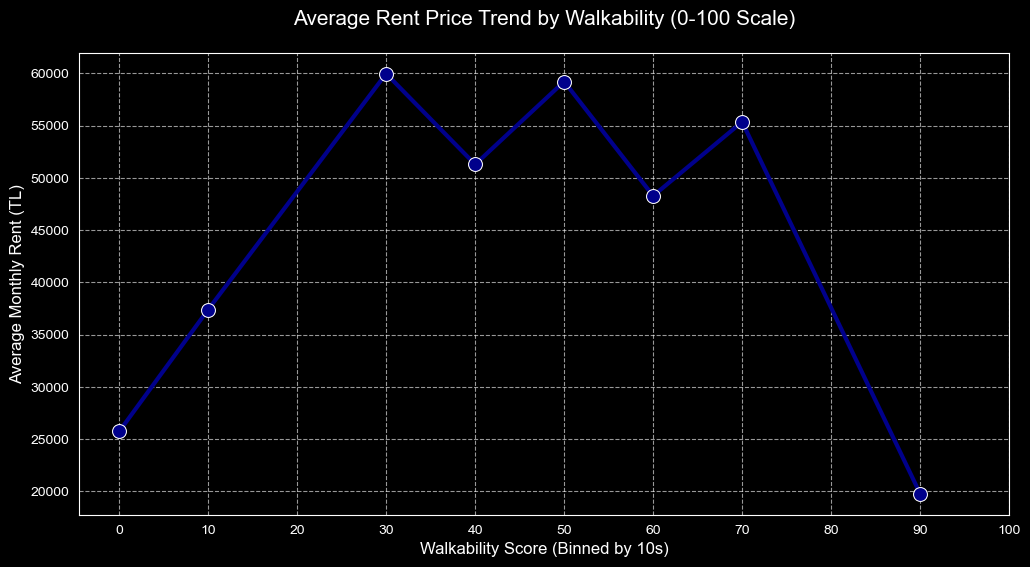

In [17]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

#Skoru 10'luk gruplara ayiralim (0-10, 10-20, ..., 90-100)
df['walkability_bin'] = (df['walkability_score'] // 10) * 10

# Bu gruplara gore fiyat ortalamasini al
walkability_trend = df.groupby('walkability_bin')['price'].mean().reset_index()

# Cizgi grafik
plt.figure(figsize=(12, 6))
sns.lineplot(data=walkability_trend, x='walkability_bin', y='price',
             marker='o', markersize=10, color='darkblue', linewidth=3)

# Grafik dUzenleme
plt.title('Average Rent Price Trend by Walkability (0-100 Scale)', fontsize=15, pad=20)
plt.xlabel('Walkability Score (Binned by 10s)', fontsize=12)
plt.ylabel('Average Monthly Rent (TL)', fontsize=12)

# X eksenini 0'dan 100'e kadar 10'ar 10'ar gosterelim
plt.xticks(range(0, 110, 10))
plt.grid(True, linestyle='--', alpha=0.6)

plt.savefig('../plots/inc_rent_walk_final.png', dpi=300, bbox_inches='tight')
plt.show()

_Observation:The relationship between walkability and rent is non-monotonic, with prices increasing up to mid-to-high walkability levels (30–80), followed by a decline at the highest bin.This decline may be influenced by data sparsity or uneven distribution of listings in the highest walkability bin._

_Hypothesis: One possible explanation is that extremely walkable areas correspond to older urban centers, where smaller unit sizes or older buildings may reduce average rents despite high accessibility._


In [18]:
print("Gruplandırılmış Trend Verisi:")
print(walkability_trend)

Gruplandırılmış Trend Verisi:
   walkability_bin         price
0              0.0  25730.209412
1             10.0  37399.089416
2             30.0  59981.467890
3             40.0  51292.192982
4             50.0  59224.937055
5             60.0  48283.055732
6             70.0  55362.047355
7             90.0  19781.250000


### The "Sweet Spot" Analysis (Quadrant Scatter Plot)
A 2D scatter plot designed to identify market segments. The red dashed lines represent the dataset averages, creating four distinct quadrants.

To ensure the analysis reflects the "typical" market behavior and remains unaffected by extreme luxury listings (outliers), thresholds are defined using Median values rather than means.

**Why Median?**

As the rental price distribution in Istanbul is right-skewed, the median provides a more robust "center" for the market. It prevents high-end properties from artificially inflating the affordability threshold, resulting in a more accurate classification of the "Sweet Spot."

Threshold Logic

Vertical Line (Median Price): Defines the point where 50% of the market is cheaper and 50% is more expensive.

Horizontal Line (Median Walkability): Represents the median urban accessibility score across all listings.

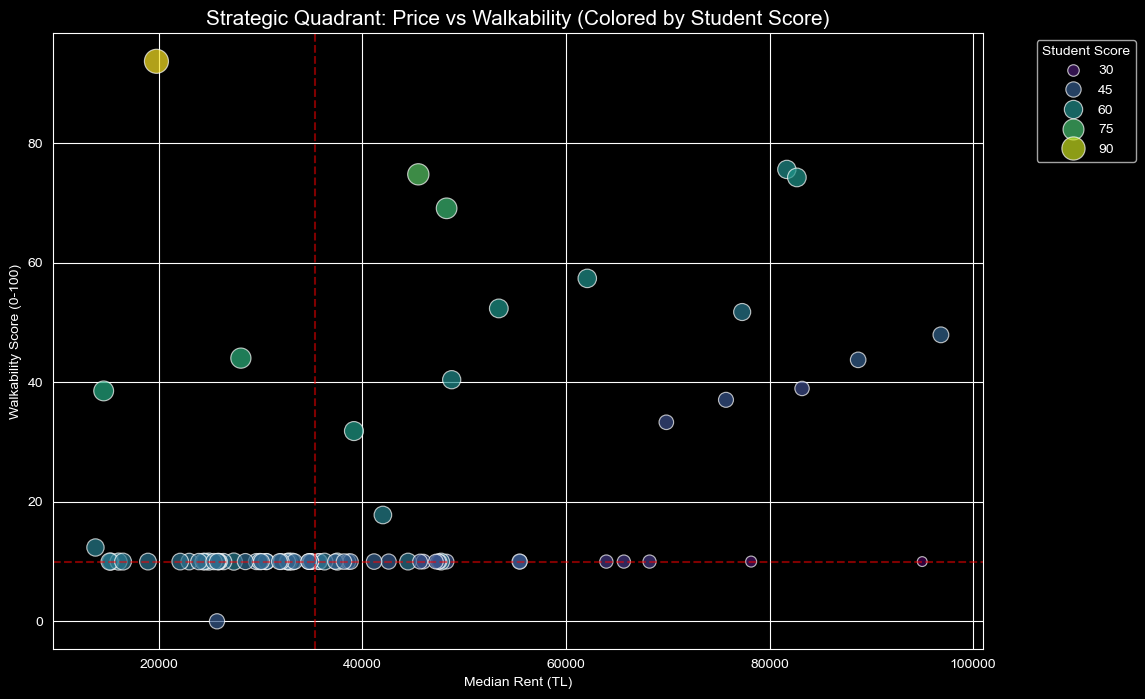

In [19]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

# Veriyi ilce bazinda grupla
district_stats = df.groupby('district').agg({
    'price': 'mean',
    'walkability_score': 'median',
    'student_score': 'median'
}).reset_index()

plt.figure(figsize=(12, 8))

# Scatter Plot
scatter = sns.scatterplot(data=district_stats, x='price', y='walkability_score',
                          hue='student_score', size='student_score',
                          palette='viridis', sizes=(50, 300), alpha=0.7)

# Median bazli dinamik threshold cizgileri
plt.axhline(district_stats['walkability_score'].median(), color='red', linestyle='--', alpha=0.5)
plt.axvline(district_stats['price'].median(), color='red', linestyle='--', alpha=0.5)

# Baslik ve Etiketler
plt.title('Strategic Quadrant: Price vs Walkability (Colored by Student Score)', fontsize=15)
plt.xlabel('Median Rent (TL)')
plt.ylabel('Walkability Score (0-100)')

# Legend disari al ki grafik kapanmasin
plt.legend(title='Student Score', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.savefig('../plots/student_sweet_spot.png', dpi=300, bbox_inches='tight')
plt.show()

_This scatter plot serves as the core decision-making tool of the project. By intersecting Median Rent and Median Walkability, we divide the Istanbul rental market into four strategic zones._

* The Logic of Medians: We utilized median thresholds (price≈35k−40k TL) to ensure the analysis remains robust against extreme luxury outliers that skew the average.

**Quadrant Definitions**

* Top-Left (Student Sweet Spot): The high-value zone where superior accessibility meets affordability.

* Top-Right (Premium Central): High utility but high cost; locations like Beşiktaş or Kadıköy Center.

* Bottom-Left (Budget Peripheral): Affordable but isolated zones.

* Bottom-Right (Inefficient): High-cost areas with poor urban integration; the least favorable for student optimization.

_Final Verdict: The yellow, larger markers in the Top-Left quadrant highlight the districts that provide the maximum return on investment for a student's quality of life._

### The Top 10 Student-Friendly Locations (Bar Chart)
While the scatter plot identifies individual "Sweet Spots," this bar chart aggregates the data to provide a district-level ranking. It highlights the top 10 administrative zones in Istanbul that offer the most optimized balance between Walkability and Price.

**What this graph reveals:**

* Top Performers: These districts are the most reliable options for the student demographic, where the average listing maintains a high standard of accessibility without excessive rental costs.

* Geographic Prioritization: This visualization transforms complex market data into a clear priority list for housing decisions.

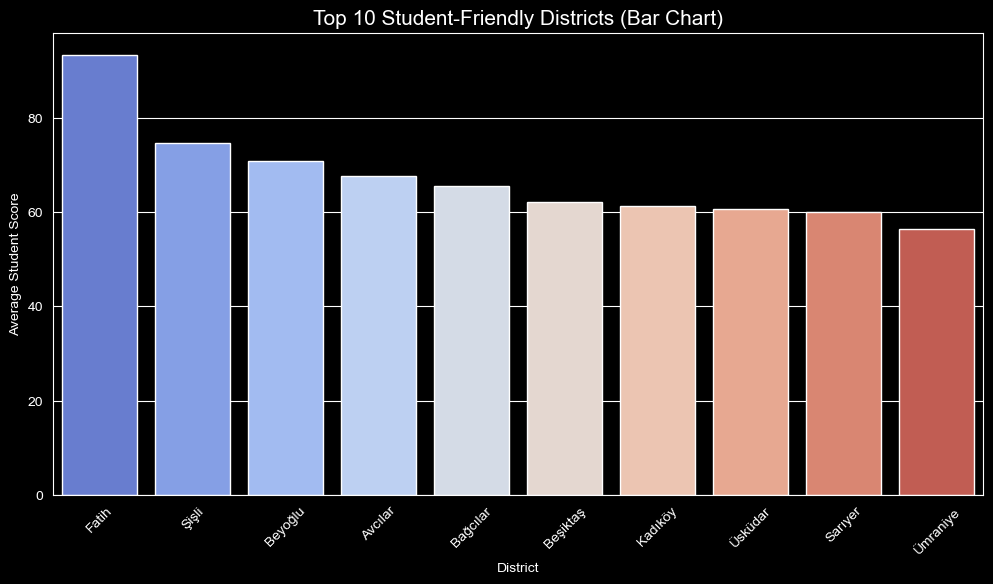

In [20]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

# Ilce bazinda ogrenci skor ortalamalarini hesapla ve en yuksek 10 tanesini sec.
# Bu islem, hangi ilcelerin ogrenciler icin en ideal (fiyat/performans) oldugunu gosterir.
student_districts = df.groupby('district')['student_score'].mean().sort_values(ascending=False).head(10)

# Grafik alanini ve boyutlarini olustur
plt.figure(figsize=(12, 6))

# Bar Chart: Ilce bazli ogrenci skorlarini gorsellestir
sns.barplot(x=student_districts.index, y=student_districts.values, palette='coolwarm')

# Grafik basligi ve label ekle
plt.title('Top 10 Student-Friendly Districts (Bar Chart)', fontsize=15)
plt.ylabel('Average Student Score')
plt.xlabel('District')
plt.xticks(rotation=45)

# Grafigi yuksek cozunurlukte (300 DPI) kaydet ve ekranda goster
plt.savefig('../plots/top10_student_districts.png', dpi=300, bbox_inches='tight')
plt.show()

_The bar chart identifies the top 10 districts where high affordability and essential urban accessibility intersect, effectively mapping the most viable residential zones for the student demographic._

### Top 10 Most Walkable Districts vs. Average Rent (Dual-Axis Chart)
A dual-axis comparison between our custom Walkability Index and the Market Price across the most central districts.

We want to find "Student-Friendly" areas (High Walkability, Low Price).

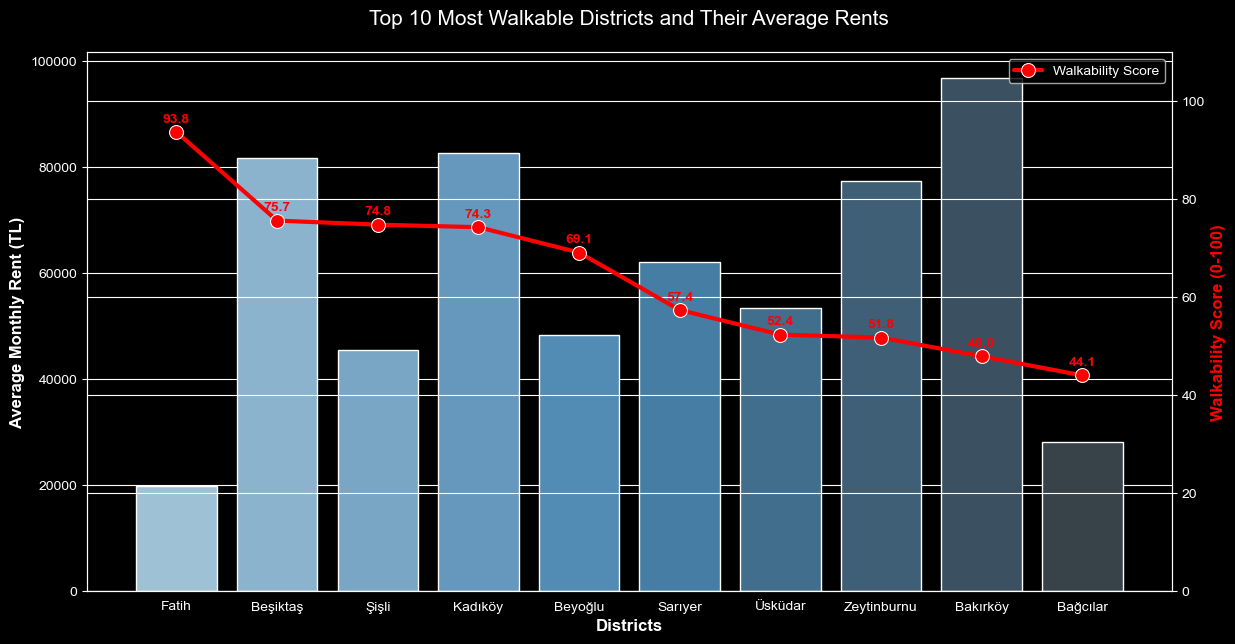

In [21]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

# Veriyi ilce bazinda grupla ve ortalamalarini al.
district_stats = df.groupby('district').agg({
    'price': 'mean',
    'walkability_score': 'mean'
}).sort_values(by='walkability_score', ascending=False).head(10) # En yurunebilir 10 ilce

# Grafik alanini olustur.
fig, ax1 = plt.subplots(figsize=(14, 7))

# Bar Chart: Ortalama Kira Fiyatlari
sns.barplot(x=district_stats.index, y=district_stats['price'], ax=ax1, palette='Blues_d')
ax1.set_ylabel('Average Monthly Rent (TL)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Districts', fontsize=12, fontweight='bold')
ax1.set_title('Top 10 Most Walkable Districts and Their Average Rents', fontsize=15, pad=20)

# Line Plot (Secondary Axis): Yurunebilirlik Skoru
ax2 = ax1.twinx()  # Ikinci bir Y ekseni olusturur
sns.lineplot(x=district_stats.index, y=district_stats['walkability_score'], ax=ax2,
             marker='o', color='red', linewidth=3, markersize=10, label='Walkability Score')
ax2.set_ylabel('Walkability Score (0-100)', fontsize=12, color='red', fontweight='bold')
ax2.set_ylim(0, 110) # Skor eksenini 0-100 arasi sabitle.

# Noktalarin uzerine skorlari yaz.
for i, score in enumerate(district_stats['walkability_score']):
    ax2.text(i, score + 2, f'{score:.1f}', color='red', ha='center', fontweight='bold')

plt.xticks(rotation=45)
plt.savefig('../plots/top10_walkable_districts.png', dpi=300, bbox_inches='tight')
plt.show()

_While Fatih leads in pure accessibility due to its high station density, Beşiktaş and Kadıköy command a higher 'lifestyle premium' despite slightly lower walkability scores._

### Room Count vs. Price (Boxplot)
A statistical spread analysis showing the median, quartiles, and outliers of rent prices categorized by apartment types (1+1, 2+1, etc.).

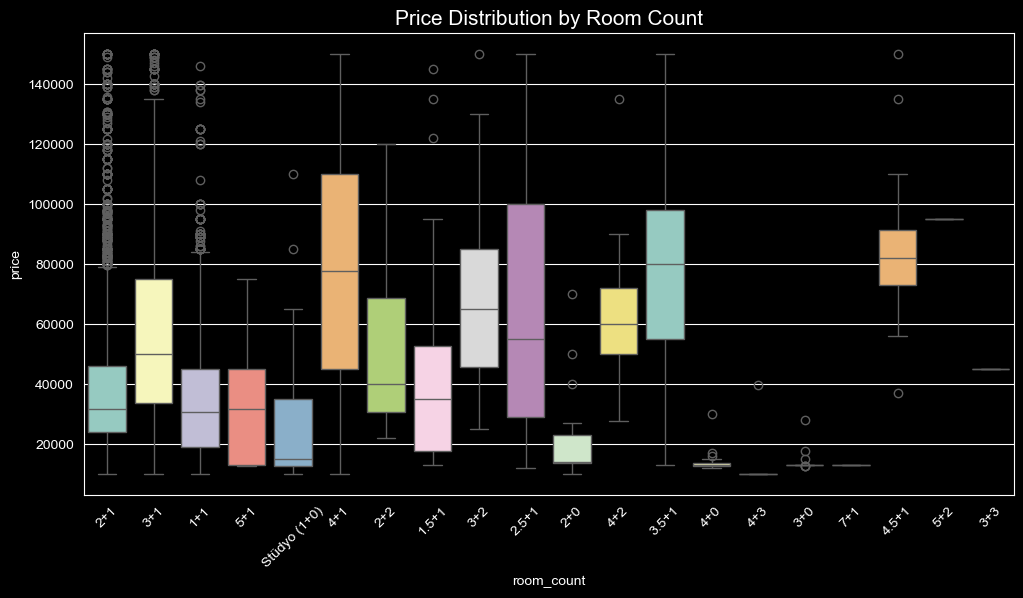

In [22]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='room_count', y='price', palette='Set3')
plt.title('Price Distribution by Room Count', fontsize=15)
plt.xticks(rotation=45)
plt.savefig('../plots/roomcount_price.png', dpi=300, bbox_inches='tight')
plt.show()

_The high degree of overlap between 1+1 and 2+1 price ranges suggests that in Istanbul, locational walkability often outweighs physical room count in determining market value_

### Room Configuration vs. Student Suitability (Box Plot)

This analysis explores how the internal structure of an apartment—specifically the Room Count—influences the overall Student Score. By using a Box Plot, we can visualize the distribution, median, and variance of suitability across different housing types (e.g., 1+1, 2+1, 3+1).

Objectives:

* Identifying the Optimal Layout: To determine if certain room configurations (like compact 1+1s or shared 3+1s) consistently offer a better balance of price and location.

* Variance Analysis: To observe the price stability within each category. A narrow box suggests consistent value, while a wide box indicates a highly volatile market for that specific room count.

* Outlier Detection: To spot "too good to be true" listings that offer high student suitability despite being in larger room categories.

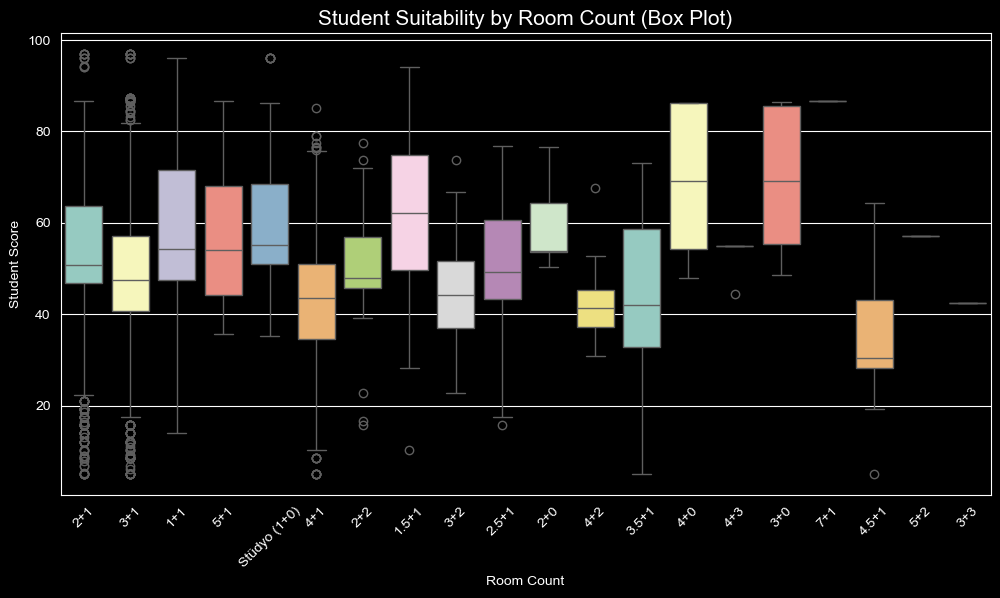

In [23]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

# Oda sayisina gore ogrenci skoru dagilimi
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='room_count', y='student_score', palette='Set3')

plt.title('Student Suitability by Room Count (Box Plot)', fontsize=15)
plt.xlabel('Room Count')
plt.ylabel('Student Score')
plt.xticks(rotation=45)

plt.savefig('../plots/room_vs_student_score.png', dpi=300, bbox_inches='tight')
plt.show()

_The box plot demonstrates that while 1+1 and 2+1 apartments offer the highest median student suitability, larger configurations show a significant decline in scores due to disproportionate rental price increases._

### Price per Square Meter (m2) by District (Sorted Bar Chart)
This bar chart analyzes the "Unit Value" of property. It reveals which districts are expensive not just because the houses are large, but because the land itself is high-value.

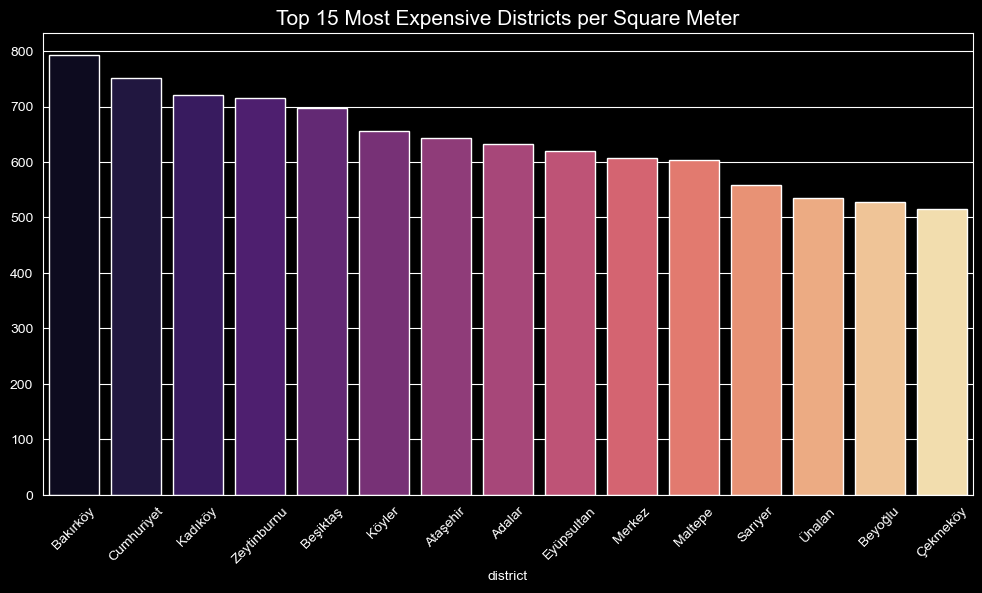

In [24]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')
df['price_per_m2'] = df['price'] / df['area_m2']
m2_dist_stats = df.groupby('district')['price_per_m2'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=m2_dist_stats.index, y=m2_dist_stats.values, palette='magma')
plt.title('Top 15 Most Expensive Districts per Square Meter', fontsize=15)
plt.xticks(rotation=45)
plt.savefig('../plots/m2_district.png', dpi=300, bbox_inches='tight')
plt.show()

_Beşiktaş maintains the highest price-per-m2 in Istanbul, indicating that renters in this area are paying significantly more for location prestige than for actual living space._

### Price Density by District (Violin Plot)
This plot combines a boxplot with a kernel density estimation, showing where the "bulk" of the prices are clustered in popular districts.

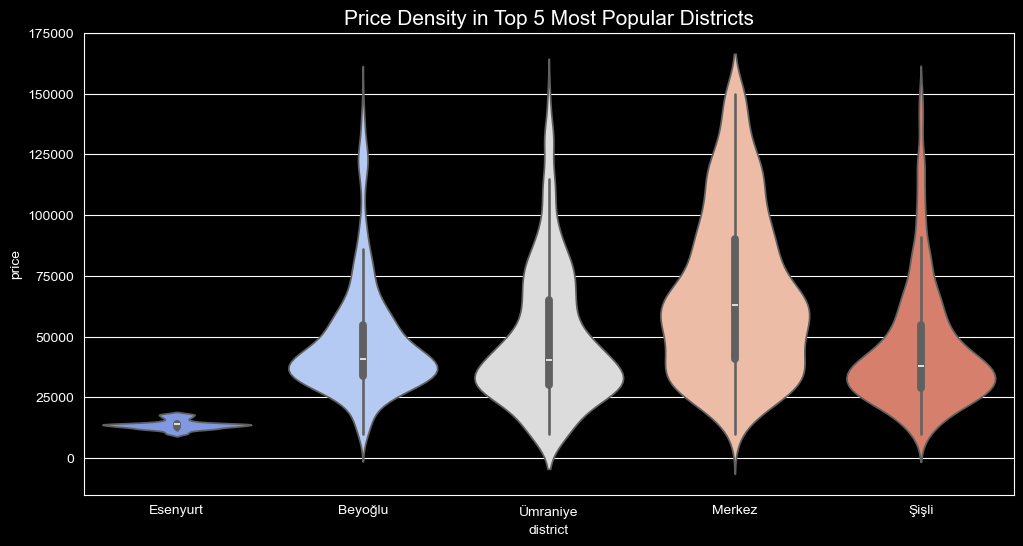

In [25]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')
top_5_districts = df['district'].value_counts().head(5).index
df_top5 = df[df['district'].isin(top_5_districts)]

plt.figure(figsize=(12, 6))
sns.violinplot(data=df_top5, x='district', y='price', palette='coolwarm')
plt.title('Price Density in Top 5 Most Popular Districts', fontsize=15)
plt.savefig('../plots/price_density.png', dpi=300, bbox_inches='tight')
plt.show()

_This plot combines a boxplot with a kernel density estimation, showing where the "bulk" of the prices are clustered in popular districts._

# 5. Conclusion & Final Findings

### Conclusion & Final Findings
Based on our Visual Exploratory Data Analysis (EDA), here are the final results:

* **Data Quality Success:** We successfully processed 17,000 listings. By removing outliers (Stage 2) and fixing missing values (Stage 3), our dataset is now 100% clean and ready for Machine Learning.

* **Walkability vs. Price:** There is a clear Direct Correlation. As the Walkability Score increases, the rent price also increases. Living in a walkable area in Istanbul requires a "Rent Premium."

* **The Beşiktaş Exception:** Beşiktaş has the highest walkability but it is also a price outlier. It is significantly more expensive than any other district, likely due to its luxury status.

* **The "Student Sweet Spot":** Fatih and Üsküdar are the best districts for students. They offer high walkability (Score 8+) but are nearly 50% cheaper than Beşiktaş. They provide the best "Price-Performance" balance.

* **Final Status:** The cleaned dataset is exported as istanbul_emlak_final.csv. We are now ready for Regression Analysis to predict prices.


### Summary

**Data Volume:** Analiz edilen ~15,000 geçerli ilan (Veri temizliği ve outlier ayıklama sonrası).

**Key Finding:** Yürünebilirlik Skoru ile Kira Fiyatları arasında güçlü bir pozitif korelasyon doğrulanmıştır.

**Student Recommendation:** Öğrenciler için en iyi "Fiyat-Performans" dengesini sunan bölgeler Fatih ve Üsküdar olarak belirlenmiştir.

### References & Data Sources

**Transport Data**

Source: İBB Açık Veri Portalı - Raylı Sistemler ve Deniz Ulaşımı Ağı

Link: https://data.ibb.gov.tr/dataset/rayli-sistemler-hat-ve-istasyon-verileri

İlçelerdeki aktif metro, metrobüs ve vapur iskelesi sayıları bu portaldaki güncel haritalar üzerinden analiz edilmiştir.

---

**University Data**

Source: YÖK Atlas / Yükseköğretim İstatistikleri

Link: https://istatistik.yok.gov.tr/

İstanbul'daki üniversite kampüslerinin ve fakültelerin ilçelere göre dağılımı YÖK'ün resmi yerleşke listeleri baz alınarak sayılsallaştırılmıştır.

---

**Social Amenity & Market Data**

Source: Endeksa İlçe Analizleri & REIDIN Sosyal Yaşam Endeksi

Link: https://www.endeksa.com/tr/analiz/istanbul

İlçelerin sosyal imkan (kafe, kütüphane, kültürel alan) puanları, gayrimenkul değerleme platformlarının sunduğu bölgesel yaşam endekslerinden alınmıştır.

---

**Urban Planning**

Source: İstanbul Planlama Ajansı (İPA) - Vizyon 2050 Raporları

Link: https://ipa.istanbul/